# Multiclass IMV — Dry Bean

One-vs-rest IMV and the pairwise IMV matrix on the UCI Dry Bean dataset
(seven classes, 16 continuous morphological features).

Like Car Evaluation, this has **no counterpart in the original notebooks**; the
published panel was hardcoded. These are new results.

**Pipeline**: download from UCI → standardise → 10 seeds × 3 estimators →
aggregate.

Full documentation: `documentation/examples/multi_imv/dry_bean.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "multi_imv_dry_bean"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imv
from imv import MulticlassIMV
from imv.utils import save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
_PATH_DISPLAY_ROOT = REPOSITORY_ROOT
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError("Expected repository package at "
                       f"{relative_path(EXPECTED_IMV_SOURCE)}, imported "
                       f"{relative_path(IMV_SOURCE)}")
print(f"imv {imv.__version__} from {relative_path(IMV_SOURCE)}")


imv 1.2.0 from src/imv


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "dry_bean", "Dry Bean"
raw = fetch_ucirepo(id=602)
frame = raw.data.features.copy()
frame["target_raw"] = raw.data.targets.iloc[:, 0].astype(str).str.strip()
print(frame.shape); print(frame["target_raw"].value_counts().to_dict())
frame.head()

(13611, 17)
{'DERMASON': 3546, 'SIRA': 2636, 'SEKER': 2027, 'HOROZ': 1928, 'CALI': 1630, 'BARBUNYA': 1322, 'BOMBAY': 522}


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,target_raw
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 2. Preprocess

In [3]:
CLASS_NAMES = sorted(frame["target_raw"].unique())
frame["target"] = frame["target_raw"].map({n: i for i, n in enumerate(CLASS_NAMES)})
FEATURES = [c for c in frame.columns if c not in ("target", "target_raw")]
frame[FEATURES] = frame[FEATURES].apply(pd.to_numeric, errors="coerce")
# Continuous features on wildly different scales; standardise so logistic
# regression converges rather than scoring a half-optimised model.
frame[FEATURES] = StandardScaler().fit_transform(frame[FEATURES])
data = frame[FEATURES + ["target"]].dropna()
data["target"] = data["target"].astype(int)
print(data.shape, len(FEATURES), "features,", len(CLASS_NAMES), "classes")
data.head()

(13611, 17) 16 features, 7 classes


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,target
0,-0.840749,-1.143319,-1.306598,-0.631153,-1.565053,-2.185720,-0.841451,-1.063341,0.289087,0.367614,1.423867,1.839116,0.680786,2.402173,1.925723,0.838371,5
1,-0.829188,-1.013924,-1.395911,-0.434445,-1.969784,-3.686040,-0.826102,-1.044217,0.697477,-0.462907,0.231054,2.495449,0.367967,3.100894,2.689702,0.771138,5
2,-0.807157,-1.078829,-1.252357,-0.585735,-1.514291,-2.045336,-0.808704,-1.008084,0.578195,0.518417,1.252865,1.764843,0.603129,2.235091,1.841356,0.916755,5
3,-0.785741,-0.977215,-1.278825,-0.439290,-1.741618,-2.742211,-0.773975,-0.973337,0.671260,-2.241767,0.515049,2.081715,0.401718,2.515075,2.204250,-0.197985,5
4,-0.781239,-1.097384,-1.380471,-0.266663,-2.117993,-4.535028,-0.784286,-0.966080,0.476020,0.804772,1.874992,2.765330,0.118268,3.270983,3.013462,0.939640,5


## 3. Estimators

In [4]:
def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(max_iter=5000, random_state=seed),
        "xgboost": lambda: XGBClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbosity=0, tree_method="hist", n_jobs=1),
        "lightgbm": lambda: LGBMClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbose=-1, n_jobs=1),
    }


## 4. One-vs-rest and pairwise IMV over ten seeds

Stratified folds are used so no fold can omit a class; the evaluator passes `model.classes_` through, so probability columns are matched to labels rather than to fold position.

In [5]:
ova_records, matrices = [], {}
for seed in SEEDS:
    frame = data.reset_index(drop=True)
    for name, factory in model_factories(seed).items():
        evaluator = MulticlassIMV(
            frame, "target", factory, n_splits=N_SPLITS,
            optional_explanatory_variables=FEATURES,
            random_state=seed, stratified=True,
        )
        _, ova_mean = evaluator.k_fold_one_vs_all()
        _, matrix_mean = evaluator.k_fold_imv_matrix()
        for label, value in zip(matrix_mean.index, ova_mean):
            ova_records.append({"seed": seed, "model": name,
                                "class": label, "one_vs_rest_imv": value})
        matrices.setdefault(name, []).append(matrix_mean)

ova = pd.DataFrame(ova_records)
ova.to_csv(RESULTS / f"{DATASET}_one_vs_rest_by_seed.csv", index=False)
mean_matrices = {name: sum(ms) / len(ms) for name, ms in matrices.items()}
for name, matrix in mean_matrices.items():
    matrix.to_csv(RESULTS / f"{DATASET}_pairwise_imv_{name}.csv")
ova.groupby(["model", "class"])["one_vs_rest_imv"].agg(["mean", "std"]).reset_index()


,model,class,mean,std
0,lightgbm,0,0.101238,0.000092
1,lightgbm,1,0.039725,0.000087
2,lightgbm,2,0.128976,0.000253
3,lightgbm,3,0.326932,0.000243
4,lightgbm,4,0.157517,0.000144
5,lightgbm,5,0.166722,0.000217
6,lightgbm,6,0.209328,0.000206
7,logistic_regression,0,0.100399,0.000095
8,logistic_regression,1,0.039839,0.000002
9,logistic_regression,2,0.128069,0.000038


## 5. Figure

The pairwise matrix is **symmetric by construction** — `ll` is invariant under `(y,p) -> (1-y,1-p)` and pairwise renormalisation gives `p_j = 1 - p_i`. Unlike the ablation matrix it carries no directional information.

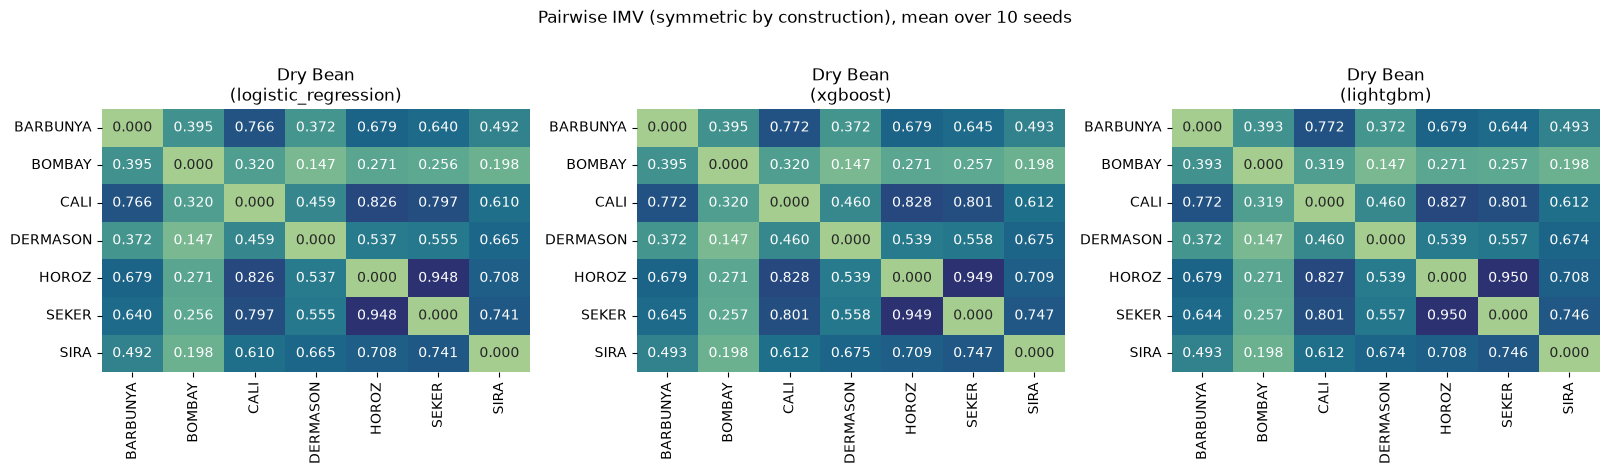

{'png': 'figures/dry_bean_pairwise_imv.png',
 'pdf': 'figures/dry_bean_pairwise_imv.pdf',
 'svg': 'figures/dry_bean_pairwise_imv.svg'}

In [6]:
fig, axes = plt.subplots(1, len(mean_matrices), figsize=(5.4 * len(mean_matrices), 4.6))
axes = np.atleast_1d(axes)
for ax, (name, matrix) in zip(axes, mean_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt=".3f", cmap="crest", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{TITLE}\n({name})")
fig.suptitle("Pairwise IMV (symmetric by construction), mean over "
             f"{len(SEEDS)} seeds", y=1.02)
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / f"{DATASET}_pairwise_imv"
         ).items()}
plt.show()
paths
